<p><font size="6" color='grey'> <b>
KI-Agenten. Planen. Handeln. Prüfen.
</b></font> </br></p>


<p><font size="5" color='grey'> <b>
Hierarchical Agent Teams
</b></font> </br></p>

---


**Beitrag zum Leitprojekt:** Eine Hierarchie lohnt sich für den Meeting- & Research-Briefing-Agent nur, wenn ein einzelner Supervisor die Fachbreite nicht mehr abdeckt — etwa wenn Recherche, Qualitätsprüfung und Freigabe getrennte Verantwortungsebenen brauchen. Genau das ist **Pruefen** auf Organisationsebene: Ohne echten Bedarf bleibt Hierarchie aber ein Architektur-Selbstzweck statt eines kontrollierten Arbeitssystems.

In [1]:
#@title 🛠️ Umgebung einrichten{ display-mode: "form" }
!uv pip install --system -q git+https://github.com/ralf-42/Agenten.git#subdirectory=04_modul

import os
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "M22-Hierarchical-Agent-Teams"
os.environ["LANGSMITH_ENDPOINT"] = "https://eu.api.smith.langchain.com"

from genai_lib.utilities import (
    check_environment,
    get_ipinfo,
    setup_api_keys,
    mprint,
    install_packages,
    mermaid,
    load_prompt,
    show_trace,
)

setup_api_keys(['OPENAI_API_KEY', 'LANGSMITH_API_KEY'], create_globals=False)
print()
check_environment()
print()
get_ipinfo()

from genai_lib.model_config import BASELINE, ROUTER, JUDGE, PLANNER, WORKER, WORKER_PREMIUM, CODING, EMBEDDINGS


✓ OPENAI_API_KEY erfolgreich gesetzt
✓ LANGSMITH_API_KEY erfolgreich gesetzt

Python Version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]

Installierte LangChain- und LangGraph-Bibliotheken:
langchain                                1.2.15
langchain-chroma                         1.1.0
langchain-classic                        1.0.4
langchain-community                      0.4.1
langchain-core                           1.3.1
langchain-ollama                         1.1.0
langchain-openai                         1.2.0
langchain-text-splitters                 1.1.2
langgraph                                1.1.9
langgraph-checkpoint                     4.0.2
langgraph-prebuilt                       1.0.10
langgraph-sdk                            0.3.13

IP-Adresse: 34.16.134.144
Hostname: 144.134.16.34.bc.googleusercontent.com
Stadt: Las Vegas
Region: Nevada
Land: US
Koordinaten: 36.1750,-115.1372
Provider: AS396982 Google LLC
Postleitzahl: 89111
Zeitzone: America/Los_Angeles


**Namenskonvention in M20-M22**

| Konzept | M20/M21 flach | M22 hierarchisch |
|---|---|---|
| Tabellenarbeit | `tabellen_worker` | `tabellen_spezialist` im Quellen-Team |
| Textarbeit | `text_worker` | `fliess_text_spezialist` im Quellen-Team |
| Synthese | `synthese_worker` | `antwort_writer` + `citation_formatter` im Synthese-Team |

Der Rollenwechsel ist bewusst: In M22 sind die Worker nicht mehr direkt am Top-Supervisor, sondern Teil eines Teams. Die fachliche Namensbasis bleibt gleich; nur die Hierarchieebene wird im Namen sichtbar.

**Zusätzliche Tool-Ebene in M21:** `tabellen_worker`/`text_worker` rufen intern die `@tool`-Funktionen `tabellen_signal_tool`/`text_signal_tool` per `.invoke()` auf, um den Befund-String zu erzeugen, und schreiben das Ergebnis anschließend als State-Feld (`tabellenbefund`/`textbefund`). Die `*_signal_tool`-Namen bezeichnen also eine Tool-Ebene unterhalb der Worker, keine eigene Rolle – in M22 entfällt diese Ebene, weil `tabellen_spezialist`/`fliess_text_spezialist` den Befund direkt erzeugen.


# 1 | Übersicht
---

M20 zeigte Multi-Agent-Pattern, M21 vertiefte den Supervisor. M22 klärt, wann eine Hierarchie sinnvoll ist: Der Top-Supervisor delegiert nicht mehr an einzelne Worker, sondern an Teams mit eigener interner Koordination.


| Flaches Supervisor-System | Hierarchisches Team-System |
|---|---|
| Top-Supervisor kennt alle Worker direkt | Top-Supervisor kennt nur Teams |
| Gut bei 2-5 klaren Rollen | Gut bei mehreren Domänen mit eigenen Unterrollen |
| Einfacher zu debuggen | Besser skalierbar, aber mehr Übergaben |
| Beispiel M21: Tabellen/Text/Vergleich direkt | Beispiel M22: Quellen-Team, Synthese-Team, Qualitäts-Team |


<p><font color='darkblue' size="4">
ℹ️ <b>Information:</b>
</font></p>

Für Mara wird Hierarchie erst relevant, wenn der Meeting- & Research-Briefing-Agent mehrere interne Teams braucht: Quellenarbeit, Antwortsynthese und Qualitätsprüfung. Eine einzelne Tabellenfrage braucht keine Hierarchie.


In [30]:
#@markdown <p><font size="4" color='green'>Flat vs. Hierarchisch im Meeting- & Research-Briefing-Agent</font></p>

diagram = """
%%{init: {'theme':'forest'}}%%
flowchart LR
    subgraph FLAT["Flat: Supervisor Pattern"]
        FS["Supervisor"] --> FT["Tabellen-Worker"]
        FS --> FX["Text-Worker"]
        FS --> FV["Vergleichs-Worker"]
    end

    subgraph HIER["Hierarchisch: Teams"]
        HS["Top Supervisor"] --> QT["Quellen-Team"]
        HS --> ST["Synthese-Team"]
        HS --> QAT["Qualitäts-Team"]

        QT --> Q1["Tabellen-Spezialist"]
        QT --> Q2["Fließtext-Spezialist"]

        ST --> S1["Antwort-Writer"]
        ST --> S2["Citation-Formatter"]

        QAT --> A1["Quellen-Gate"]
        QAT --> A2["Out-of-Corpus-Check"]
    end

    %% Styles für das Flat Pattern (Dezent/Graublau)
    style FS fill:#607D8B,color:#fff
    style FT fill:#CFD8DC,color:#000
    style FX fill:#CFD8DC,color:#000
    style FV fill:#CFD8DC,color:#000

    %% Styles für das Hierarchische Pattern
    style HS fill:#FF9800,color:#fff,stroke:#e68a00,stroke-width:2px

    %% Team Quellen (Blau)
    style QT fill:#2196F3,color:#fff
    style Q1 fill:#BBDEFB,color:#000
    style Q2 fill:#BBDEFB,color:#000

    %% Team Synthese (Grün)
    style ST fill:#4CAF50,color:#fff
    style S1 fill:#C8E6C9,color:#000
    style S2 fill:#C8E6C9,color:#000

    %% Team Qualität (Lila)
    style QAT fill:#9C27B0,color:#fff
    style A1 fill:#E1BEE7,color:#000
    style A2 fill:#E1BEE7,color:#000
"""

mermaid(diagram, width=980)


# 2 | Anti-Pattern: Hierarchie ohne echten Bedarf
---

Hierarchie löst nicht jedes Problem. Wenn eine einfache Kennzahlfrage durch einen Tabellen-Worker beantwortet werden kann, erzeugen Top-Supervisor, Lead und mehrere Specialists nur Overhead.


In [3]:
einfache_frage = "Welche Precision@3 wurde im Research-Eval-Set gemessen?"

hierarchie_plan = [
    "Top Supervisor klassifiziert Frage",
    "Quellen-Team Lead plant Tabellenarbeit",
    "Tabellen-Spezialist extrahiert Kennzahl",
    "Synthese-Team Lead plant Antwort",
    "Antwort-Writer formuliert Satz",
    "Qualitäts-Team prüft Quellenhinweis",
]

for schritt in hierarchie_plan:
    print("- " + schritt)

assert len(hierarchie_plan) > 4, "Das Anti-Pattern soll unnötigen Overhead sichtbar machen."
print("Anti-Pattern sichtbar: Für eine einzelne Kennzahlfrage ist die Hierarchie überdimensioniert.")


- Top Supervisor klassifiziert Frage
- Quellen-Team Lead plant Tabellenarbeit
- Tabellen-Spezialist extrahiert Kennzahl
- Synthese-Team Lead plant Antwort
- Antwort-Writer formuliert Satz
- Qualitäts-Team prüft Quellenhinweis
Anti-Pattern sichtbar: Für eine einzelne Kennzahlfrage ist die Hierarchie überdimensioniert.


# 3 | Drei-Ebenen-Hierarchie
---

Die robuste Variante trennt Ebenen und Zuständigkeiten. Jeder Team-Lead gibt nur ein kompaktes Paket an den Top-Supervisor zurück.


In [29]:
#@markdown <p><font size="4" color='green'>Drei-Ebenen-Hierarchie</font></p>

diagram = """
%%{init: {'theme':'forest'}}%%
flowchart TD
    TOP["<b>Ebene 1: Top Supervisor<br/>Team-Routing</b>"]

    subgraph Q["<b>Ebene 2: Quellen-Team</b>"]
        QL["Quellen Lead"] --> TAB["Ebene 3: Tabellen-Spezialist"]
        QL --> TXT["Ebene 3: Fließtext-Spezialist"]
    end

    subgraph S["<b>Ebene 2: Synthese-Team</b>"]
        SL["Synthese Lead"] --> WR["Ebene 3: Antwort-Writer"]
        SL --> CIT["Ebene 3: Citation-Formatter"]
    end

    subgraph QA["<b>Ebene 2: Qualitäts-Team</b>"]
        AL["Qualitäts Lead"] --> SRC["Ebene 3: Quellen-Gate"]
        AL --> OOC["Ebene 3: Out-of-Corpus-Check"]
    end

    TOP --> QL
    TOP --> SL
    TOP --> AL

    %% Styles für die Ebenen und Teams
    style TOP fill:#FF9800,color:#fff,stroke:#e68a00,stroke-width:2px

    style QL fill:#2196F3,color:#fff
    style TAB fill:#BBDEFB,color:#000
    style TXT fill:#BBDEFB,color:#000

    style SL fill:#4CAF50,color:#fff
    style WR fill:#C8E6C9,color:#000
    style CIT fill:#C8E6C9,color:#000

    style AL fill:#9C27B0,color:#fff
    style SRC fill:#E1BEE7,color:#000
    style OOC fill:#E1BEE7,color:#000
"""

mermaid(diagram, width=920)


In [5]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image as IPImage

class HierarchieState(TypedDict):
    frage: str
    quellenpaket: str
    synthese_entwurf: str
    finale_antwort: str
    qualitaetsstatus: str
    freigegeben: bool
    log: list[str]


def log_plus(state: HierarchieState, eintrag: str) -> list[str]:
    return state.get("log", []) + [eintrag]

print("Hierarchie-State ist bereit.")


Hierarchie-State ist bereit.


<p><font color='darkblue' size="4">
  <b>Wichtig:</b>
</font></p>

Die Hierarchie muss die Übergaben reduzieren, nicht vergrößern. Team-Leads geben deshalb kompakte Pakete zurück: Quellenpaket, Syntheseentwurf, Qualitätsstatus.


# 4 | Teams als Subgraphen
---

In diesem Notebook werden Teams als Subgraphen modelliert. Das macht die Zuständigkeiten sichtbar und bleibt ohne Modellaufrufe reproduzierbar.


In [6]:
def tabellen_spezialist(state: HierarchieState) -> dict:
    befund = "Tabelle: Precision@3 = 0.77 im Research-Eval-Set."
    return {"quellenpaket": befund, "log": log_plus(state, "Tabellen-Spezialist liefert Kennzahl")}


def fliess_text_spezialist(state: HierarchieState) -> dict:
    paket = state["quellenpaket"] + " Text: Quellenhinweise machen Antworten prüfbar."
    return {"quellenpaket": paket, "log": log_plus(state, "Fließtext-Spezialist ergänzt Argument")}


quellen_builder = StateGraph(HierarchieState)
quellen_builder.add_node("tabellen_spezialist", tabellen_spezialist)
quellen_builder.add_node("fliess_text_spezialist", fliess_text_spezialist)
quellen_builder.add_edge(START, "tabellen_spezialist")
quellen_builder.add_edge("tabellen_spezialist", "fliess_text_spezialist")
quellen_builder.add_edge("fliess_text_spezialist", END)
quellen_team = quellen_builder.compile()
print("Quellen-Team kompiliert.")


Quellen-Team kompiliert.


In [7]:
def antwort_writer(state: HierarchieState) -> dict:
    entwurf = "Antwort: " + state["quellenpaket"]
    return {"synthese_entwurf": entwurf, "log": log_plus(state, "Antwort-Writer erstellt Entwurf")}


def citation_formatter(state: HierarchieState) -> dict:
    antwort = state["synthese_entwurf"] + " Quelle: fachartikel_rag_evaluation.pdf."
    return {"finale_antwort": antwort, "log": log_plus(state, "Citation-Formatter ergänzt Quelle")}


synthese_builder = StateGraph(HierarchieState)
synthese_builder.add_node("antwort_writer", antwort_writer)
synthese_builder.add_node("citation_formatter", citation_formatter)
synthese_builder.add_edge(START, "antwort_writer")
synthese_builder.add_edge("antwort_writer", "citation_formatter")
synthese_builder.add_edge("citation_formatter", END)
synthese_team = synthese_builder.compile()
print("Synthese-Team kompiliert.")


Synthese-Team kompiliert.


In [8]:
def quellen_gate(state: HierarchieState) -> dict:
    status = "belegt" if "Quelle:" in state.get("finale_antwort", "") else "quelle_fehlt"
    return {"qualitaetsstatus": status, "log": log_plus(state, f"Quellen-Gate: {status}")}


def out_of_corpus_check(state: HierarchieState) -> dict:
    freigegeben = state.get("qualitaetsstatus") == "belegt" and "Nicht im Korpus" not in state.get("finale_antwort", "")
    return {"freigegeben": freigegeben, "log": log_plus(state, f"Out-of-Corpus-Check: {'freigegeben' if freigegeben else 'gesperrt'}")}


qualitaet_builder = StateGraph(HierarchieState)
qualitaet_builder.add_node("quellen_gate", quellen_gate)
qualitaet_builder.add_node("out_of_corpus_check", out_of_corpus_check)
qualitaet_builder.add_edge(START, "quellen_gate")
qualitaet_builder.add_edge("quellen_gate", "out_of_corpus_check")
qualitaet_builder.add_edge("out_of_corpus_check", END)
qualitaets_team = qualitaet_builder.compile()
print("Qualitäts-Team kompiliert.")


Qualitäts-Team kompiliert.


In [9]:
haupt_builder = StateGraph(HierarchieState)
haupt_builder.add_node("quellen_team", quellen_team)
haupt_builder.add_node("synthese_team", synthese_team)
haupt_builder.add_node("qualitaets_team", qualitaets_team)
haupt_builder.add_edge(START, "quellen_team")
haupt_builder.add_edge("quellen_team", "synthese_team")
haupt_builder.add_edge("synthese_team", "qualitaets_team")
haupt_builder.add_edge("qualitaets_team", END)

hierarchie_graph = haupt_builder.compile()
print("Hierarchischer Hauptgraph kompiliert.")


Hierarchischer Hauptgraph kompiliert.


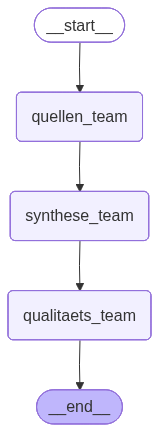

In [10]:
display(IPImage(hierarchie_graph.get_graph().draw_mermaid_png()))

In [11]:
run_cfg = {"run_name": "M22-Hierarchie-Grundlauf", "tags": ["m22", "hierarchie", "research"]}

hierarchie_result = hierarchie_graph.invoke(
    {
        "frage": "Welche Evidenz spricht für RAG-Evaluation mit Quellenhinweisen?",
        "quellenpaket": "",
        "synthese_entwurf": "",
        "finale_antwort": "",
        "qualitaetsstatus": "",
        "freigegeben": False,
        "log": [],
    },
    config=run_cfg,
)

mprint("**Hierarchie-Log:**")
for eintrag in hierarchie_result["log"]:
    print("- " + eintrag)

mprint("**Finale Antwort:**")
print(hierarchie_result["finale_antwort"])
print("Freigegeben:", hierarchie_result["freigegeben"])

**Hierarchie-Log:**

- Tabellen-Spezialist liefert Kennzahl
- Fließtext-Spezialist ergänzt Argument
- Antwort-Writer erstellt Entwurf
- Citation-Formatter ergänzt Quelle
- Quellen-Gate: belegt
- Out-of-Corpus-Check: freigegeben


**Finale Antwort:**

Antwort: Tabelle: Precision@3 = 0.77 im Research-Eval-Set. Text: Quellenhinweise machen Antworten prüfbar. Quelle: fachartikel_rag_evaluation.pdf.
Freigegeben: True


# 5 | Sequenziell, parallel und überdimensioniert
---

Hierarchie ist nicht automatisch parallel. Quellen-Team → Synthese-Team → Qualitäts-Team ist bewusst sequenziell, weil jedes Team das Paket des vorherigen Teams benötigt. Parallelität lohnt sich nur bei unabhängigen Teams.


In [12]:
import time
from concurrent.futures import ThreadPoolExecutor


def research_team_a() -> str:
    time.sleep(0.05)
    return "Team A: Retrieval-Treffer geprüft."


def research_team_b() -> str:
    time.sleep(0.05)
    return "Team B: Antwortqualität geprüft."


def sequenziell_messen() -> dict:
    start = time.perf_counter()
    a = research_team_a()
    b = research_team_b()
    return {"modus": "sequenziell", "ms": round((time.perf_counter() - start) * 1000), "ergebnisse": [a, b]}


def parallel_messen() -> dict:
    start = time.perf_counter()
    with ThreadPoolExecutor(max_workers=2) as pool:
        a = pool.submit(research_team_a)
        b = pool.submit(research_team_b)
        ergebnisse = [a.result(), b.result()]
    return {"modus": "parallel", "ms": round((time.perf_counter() - start) * 1000), "ergebnisse": ergebnisse}

seq = sequenziell_messen()
par = parallel_messen()
print("Sequenziell:", seq["ms"], "ms")
print("Parallel:", par["ms"], "ms")
print("Ergebnisse:", " | ".join(par["ergebnisse"]))


Sequenziell: 101 ms
Parallel: 57 ms
Ergebnisse: Team A: Retrieval-Treffer geprüft. | Team B: Antwortqualität geprüft.


<p><font color='darkblue' size="4">
✨ <b>Empfehlung:</b>
</font></p>

Hierarchie ist passend, wenn mehrere Teams unabhängig intern arbeiten und nur verdichtete Pakete an die nächste Ebene geben. Bei einfachen Standardabläufen bleibt die Pipeline aus M20 oder der Supervisor aus M21 günstiger und leichter prüfbar.


# 6 | Debugging mit Trace und Log
---

Bei hierarchischen Systemen ist das Log wichtiger als die finale Antwort. Es zeigt, ob Teams in der richtigen Reihenfolge arbeiten und ob Qualitäts-Gates wirklich ausgeführt wurden.


In [31]:
#@markdown <p><font size="4" color='green'>LangSmith Trace-Analyse</font></p>

try:
    show_trace("M22-Hierarchical-Agent-Teams", limit=3, show_steps=True)
except Exception as exc:
    print("Trace-Anzeige übersprungen:", type(exc).__name__, str(exc)[:180])


## LangSmith Trace — `M22-Hierarchical-Agent-Teams`

| Run | Status | Dauer | Child-Runs |
|-----|--------|-------|------------|
| `M22-Aufgabe-Aufbau` | ✅ success | 0.1s | 0 |
| `M22-Aufgabe-Grundlagen` | ✅ success | 0.1s | 0 |
| `M22-Hierarchie-Grundlauf` | ✅ success | 0.1s | 0 |


### Steps — letzter Run: `M22-Aufgabe-Aufbau`

| # | Typ | Name | Status | Dauer |
|---|-----|------|--------|-------|
| 1 | `chain` | `qualitaets_team` | ✅ | 0.0s |
| 2 | `chain` | `synthese_team` | ✅ | 0.0s |
| 3 | `chain` | `quellen_team` | ✅ | 0.0s |

# A | Aufgaben
---

<p><font color='darkblue' size="4">
✏️  <b>Notiz:</b>
</font></p>

Die Aufgabenstellungen prüfen, ob eine Hierarchie fachlich begründet und nicht nur dekorativ ist. Jeder Selfcheck steht direkt unter der zugehörigen Umsetzung.


**Grundlagen**

Eine Hierarchie mit mindestens zwei Teams benennen und ausführen. Das Ergebnis muss zeigen, welche Teams gearbeitet haben.

**Erledigt wenn:** `mein_hierarchie_graph` kompiliert ist und `grundlagen_result` ein Log mit Quellen-Team und Synthese-Team enthält.


In [14]:
mein_hierarchie_graph = hierarchie_graph
run_cfg = {"run_name": "M22-Aufgabe-Grundlagen", "tags": ["m22", "aufgabe", "grundlagen"]}

grundlagen_result = mein_hierarchie_graph.invoke(
    {
        "frage": "Welche Rolle haben Quellenhinweise in der RAG-Evaluation?",
        "quellenpaket": "",
        "synthese_entwurf": "",
        "finale_antwort": "",
        "qualitaetsstatus": "",
        "freigegeben": False,
        "log": [],
    },
    config=run_cfg,
)

print(" | ".join(grundlagen_result["log"]))


Tabellen-Spezialist liefert Kennzahl | Fließtext-Spezialist ergänzt Argument | Antwort-Writer erstellt Entwurf | Citation-Formatter ergänzt Quelle | Quellen-Gate: belegt | Out-of-Corpus-Check: freigegeben


In [15]:
# ✅ Selbstcheck Grundlagen
assert "mein_hierarchie_graph" in globals(), "mein_hierarchie_graph fehlt."
assert hasattr(mein_hierarchie_graph, "invoke"), "mein_hierarchie_graph ist kein kompilierter Graph."
log_text = " ".join(grundlagen_result.get("log", []))
assert "Tabellen-Spezialist" in log_text, "Quellen-Team/Tabellen-Spezialist fehlt im Log."
assert "Antwort-Writer" in log_text, "Synthese-Team/Antwort-Writer fehlt im Log."
print("✅ Grundlagen-Selfcheck bestanden.")


✅ Grundlagen-Selfcheck bestanden.


**Aufbau**

Ein Qualitäts-Team mit Quellen-Gate und Out-of-Corpus-Check verwenden. Die finale Antwort darf nur freigegeben werden, wenn ein Quellenhinweis vorhanden ist.

**Erledigt wenn:** `aufbau_result` enthält `qualitaetsstatus='belegt'`, `freigegeben=True` und eine finale Antwort mit `Quelle:`.


In [16]:
run_cfg = {"run_name": "M22-Aufgabe-Aufbau", "tags": ["m22", "aufgabe", "aufbau"]}
aufbau_result = mein_hierarchie_graph.invoke(
    {
        "frage": "Welche Kennzahl und welches Argument stützen die RAG-Evaluation?",
        "quellenpaket": "",
        "synthese_entwurf": "",
        "finale_antwort": "",
        "qualitaetsstatus": "",
        "freigegeben": False,
        "log": [],
    },
    config=run_cfg,
)

print(aufbau_result["qualitaetsstatus"])
print(aufbau_result["finale_antwort"])


belegt
Antwort: Tabelle: Precision@3 = 0.77 im Research-Eval-Set. Text: Quellenhinweise machen Antworten prüfbar. Quelle: fachartikel_rag_evaluation.pdf.


In [17]:
# ✅ Selbstcheck Aufbau
assert aufbau_result.get("qualitaetsstatus") == "belegt", "Qualitätsstatus ist nicht belegt."
assert aufbau_result.get("freigegeben") is True, "Qualitäts-Team hat die belegte Antwort nicht freigegeben."
assert "Quelle:" in aufbau_result.get("finale_antwort", ""), "Quellenhinweis fehlt."
print("✅ Aufbau-Selfcheck bestanden.")


✅ Aufbau-Selfcheck bestanden.


**Vertiefung**

Parallelität nur für unabhängige Teams nutzen und begründen, wann Hierarchie überdimensioniert ist.

**Erledigt wenn:** `par` enthält zwei Ergebnisse und ist schneller als oder ähnlich schnell wie `seq`; `hierarchie_grenze` benennt einen Fall, in dem ein flaches Pattern genügt.


In [18]:
hierarchie_grenze = "Eine einzelne Kennzahlfrage genügt als flacher Tabellen-Worker oder Pipeline-Schritt."

print("Sequenziell:", seq["ms"], "ms")
print("Parallel:", par["ms"], "ms")
print(hierarchie_grenze)


Sequenziell: 101 ms
Parallel: 57 ms
Eine einzelne Kennzahlfrage genügt als flacher Tabellen-Worker oder Pipeline-Schritt.


In [19]:
# ✅ Selbstcheck Vertiefung
assert len(par.get("ergebnisse", [])) == 2, "Parallel-Lauf enthält nicht zwei Ergebnisse."
assert par.get("ms", 9999) <= seq.get("ms", 0) * 1.5, "Parallel-Lauf ist unerwartet deutlich langsamer."
assert "flach" in hierarchie_grenze.lower() or "pipeline" in hierarchie_grenze.lower(), "Grenze der Hierarchie wird nicht benannt."
print("✅ Vertiefung-Selfcheck bestanden.")


✅ Vertiefung-Selfcheck bestanden.


<p><font color='darkblue' size="4">
✨ <b>Empfehlung:</b>
</font></p>

M22 ist die Grenze zwischen nützlicher Struktur und Organisations-Overhead. Für den Freitag-Capstone reicht oft ein Supervisor mit zwei Spezialisten; eine Hierarchie ist die Erweiterung, wenn der eigene Korpus mehrere klar getrennte Arbeitsteams erfordert.


<p><font color='darkblue' size="4">
 <b>Viz</b>
</font></p>

- [KI-Agenten-Architektur](https://editor.p5js.org/ralf.bendig.rb/full/Viso2emNI)
- [LangGraph](https://editor.p5js.org/ralf.bendig.rb/full/EUzaFq4C4)


# B | Dokumente zum Weiterlesen
---

Ergänzende Artikel aus der Kurs-Dokumentation:

- [Multi-Agent-Systeme](https://ralf-42.github.io/Agenten/06-multi-agent-erweiterungen/multi-agent-systeme.html)
- [Agenten-Kommunikationsprotokolle](https://ralf-42.github.io/Agenten/06-multi-agent-erweiterungen/agenten-kommunikationsprotokolle.html)
- [LangGraph Best Practices](https://ralf-42.github.io/Agenten/05-frameworks/langgraph-best-practices.html)
- [Agenten-Architekturen](https://ralf-42.github.io/Agenten/04-agenten-implementierung/entwurf/agent-architekturen.html)
- [Skills](https://ralf-42.github.io/Agenten/06-multi-agent-erweiterungen/skills.html)
